In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize, curve_fit
from scipy.stats import multivariate_normal, lognorm, norm
from sklearn.linear_model import LinearRegression

from numpy.polynomial import Polynomial

from help_functions_non_njit import *
from graph_format import *

# Indbetalingsprocent

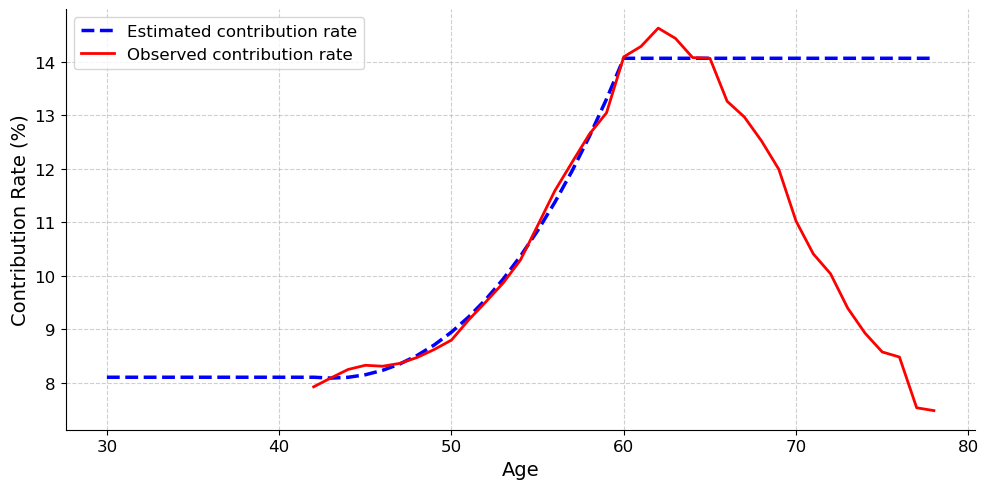

In [24]:
# Load and clean data
df_original = pd.read_csv("Data_cohort/employer_percent.csv")
df_original = df_original[["age", "alder_amr"]].dropna().sort_values("age").copy()

# Data used for fitting: only ages up to 60
df_fit = df_original[df_original["age"] <= 60].copy()

# Observed series
ages_obs_original = df_original["age"].to_numpy()
indbet_original = df_original["alder_amr"].to_numpy()

# Fit series
ages_fit = df_fit["age"].to_numpy()
indbet_fit = df_fit["alder_amr"].to_numpy()

# Fit polynomial on ages up to 60
coefs = Polynomial.fit(ages_fit, indbet_fit, deg=3)

# Create smooth age grid from 30 to max observed age
max_age = int(100)
ages_smooth = np.arange(30, max_age + 1)
y_smooth = np.empty_like(ages_smooth, dtype=float)

# Polynomial values up to age 60
mask_le_60 = ages_smooth <= 60
y_smooth[mask_le_60] = coefs(ages_smooth[mask_le_60])

# Keep values before first observed fitting age constant
first_fit_age = int(df_fit["age"].min())
mask_before_fit = ages_smooth < first_fit_age
if mask_before_fit.any():
    first_valid_idx = np.where(ages_smooth == first_fit_age)[0][0]
    y_smooth[mask_before_fit] = y_smooth[first_valid_idx]

# Keep values after age 60 constant at the age-60 value
mask_gt_60 = ages_smooth > 60
if mask_gt_60.any():
    y60 = y_smooth[ages_smooth == 60][0]
    y_smooth[mask_gt_60] = y60

# Save smoothed data to CSV
pd.DataFrame(y_smooth).to_csv("Smooth_data/smooth_indbet_employer.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    ages_smooth[0:df_original["age"].max()+1-30],
    y_smooth[0:df_original["age"].max()+1-30] * 100,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label="Estimated contribution rate"
)

ax.plot(
    ages_obs_original,
    indbet_original * 100,
    color="red",
    linestyle="-",
    linewidth=2,
    label="Observed contribution rate"
)

ax.set_xlabel("Age", fontsize=14)
ax.set_ylabel("Contribution Rate (%)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best", frameon=True, fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

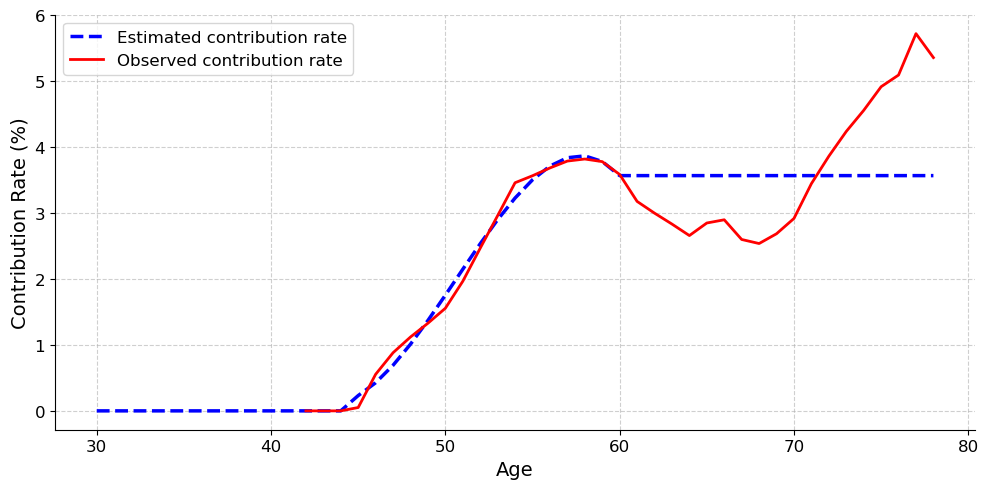

In [26]:
# Load and clean full original data
df_original = pd.read_csv("Data_cohort/private_percent.csv")
df_original = df_original[["age", "alder_amr"]].dropna().sort_values("age").copy()

# Data used for fitting: only ages 45 to 60
df_fit = df_original[(df_original["age"] >= 45) & (df_original["age"] <= 60)].copy()

# Original observed series
ages_obs_original = df_original["age"].to_numpy()
indbet_original = df_original["alder_amr"].to_numpy()

# Fit series
ages_fit = df_fit["age"].to_numpy()
indbet_fit = df_fit["alder_amr"].to_numpy()

# Fit polynomial on ages 45 to 60
coefs = Polynomial.fit(ages_fit, indbet_fit, deg=3)

# Create smooth age grid from 30 to max observed age
max_age = int(100)
ages_smooth = np.arange(30, max_age + 1)
y_smooth = np.empty_like(ages_smooth, dtype=float)

# Polynomial values from 45 to 60
mask_fit_range = (ages_smooth >= ages_fit.min()) & (ages_smooth <= 60)
y_smooth[mask_fit_range] = coefs(ages_smooth[mask_fit_range])

# Set values before 45 to zero
mask_before_fit = ages_smooth < ages_fit.min()
y_smooth[mask_before_fit] = 0.0

# Keep values after age 60 constant at the age-60 value
mask_after_60 = ages_smooth > 60
if mask_after_60.any():
    y60 = coefs(60)
    y_smooth[mask_after_60] = y60

# Save smoothed data to CSV
pd.DataFrame(y_smooth).to_csv("Smooth_data/smooth_indbet_private.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    ages_smooth[0:df_original["age"].max()+1-30],
    y_smooth[0:df_original["age"].max()+1-30] * 100,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label="Estimated contribution rate"
)

ax.plot(
    ages_obs_original,
    indbet_original * 100,
    color="red",
    linestyle="-",
    linewidth=2,
    label="Observed contribution rate"
)

ax.set_xlabel("Age", fontsize=14)
ax.set_ylabel("Contribution Rate (%)", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="best", frameon=True, fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

# Overlevelses ssh

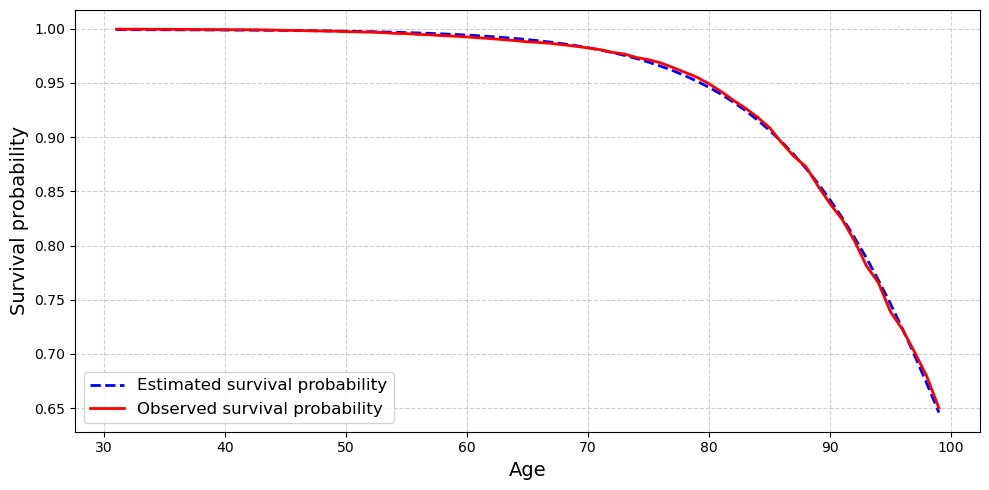

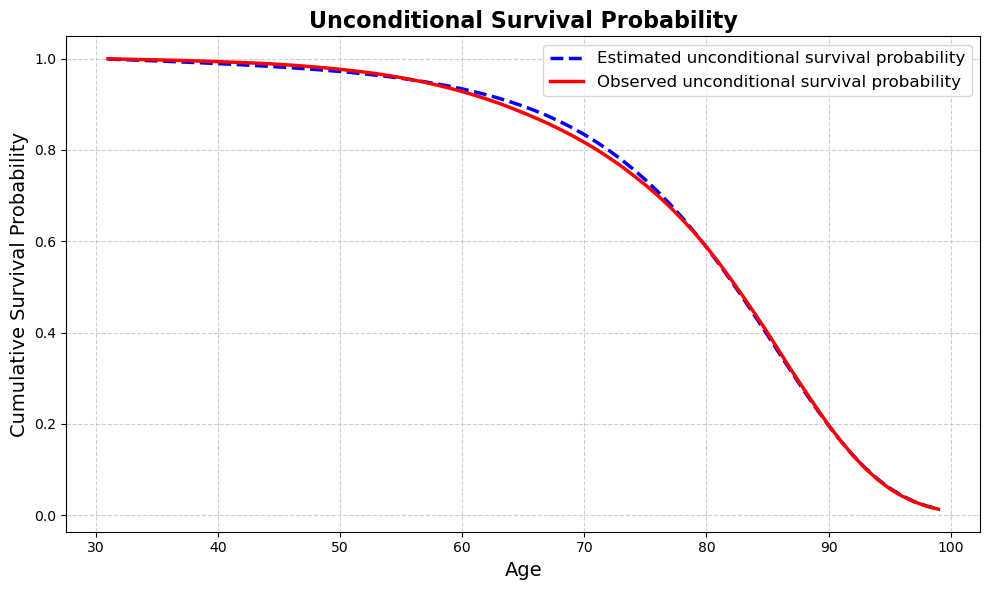

In [11]:
# Define logistic function
def logistic(x, L, f, x0):
    return L / (1 + np.exp(-f * (x - x0)))

# Load and process data
df = pd.read_csv("Data/overlevelse_ssh.csv")
L, f, x0 = 0.9992, -0.1195, 74.0520
df["predicted"] = logistic(df["alder"], L, f, x0)
df["observed_unconditional"] = np.cumprod(df["survival_Mean"])
df["predicted_unconditional"] = np.cumprod(df["predicted"])

# === Conditional Survival Plot ===
plt.figure(figsize=(10, 5))
plt.plot(
    df["alder"] + 30,
    df["predicted"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Estimated survival probability"
)
plt.plot(
    df["alder"] + 30,
    df["survival_Mean"],
    color="red",
    linestyle="-",
    linewidth=2,
    label="Observed survival probability"
)

plt.xlabel("Age", fontsize=14)
plt.ylabel("Survival probability", fontsize=14)
plt.title("", fontsize=16, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# === Unconditional Survival Plot ===
plt.figure(figsize=(10, 6))
plt.plot(
    df["alder"] + 30,
    df["predicted_unconditional"],
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label="Estimated unconditional survival probability"
)
plt.plot(
    df["alder"] + 30,
    df["observed_unconditional"],
    color="red",
    linestyle="-",
    linewidth=2.5,
    label="Observed unconditional survival probability"
)

plt.xlabel("Age", fontsize=14)
plt.ylabel("Cumulative Survival Probability", fontsize=14)
plt.title("Unconditional Survival Probability", fontsize=16, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Save predicted survival data
df[["alder", "predicted"]].to_csv("Smooth_data/survival_ssh.csv", index=False)

# Transitions ssh for employment

In [12]:
df = pd.read_csv("Data/parameter_estimates_simpel.csv")[['Variable', 'Response',  'Estimate']]


# state_1_multiplier = 2

everything = []
# for e_state_lag in [0.0, 1.0]:
total_1 = []
total_2 = []
for x in range(70):
    eta = {1: 0.0, 2: 0.0}

    for e_state in [1.0, 2.0]: 
        df_state = df[df['Response'] == e_state]
        for _, row in df_state.iterrows():
            var = row["Variable"]
            estimate = row["Estimate"]
            
            if var == 'Intercept':
                eta[e_state] = estimate
            elif var == 'alder':
                eta[e_state] += estimate * x
            # elif var == 'alder2':
            #     eta[e_state] += estimate * x**2
            elif var == "dummy_60_65":
                if x >= 31:
                    eta[e_state] += estimate

    total_1.append(eta[1])
    total_2.append(eta[2])


group_0 = []
group_1 = []    
group_2 = []
for x in range(70):
    # if 40 > x >= 35:
    #     group_0.append(0.0)
    #     group_1.append(np.exp(total_1[x])/(np.exp(total_1[x]) + np.exp(total_2[x])))
    #     group_2.append(np.exp(total_2[x])/(np.exp(total_1[x]) + np.exp(total_2[x])))
    # elif 40 > x > 35:
    #     group_0.append(0.0)
    #     group_1.append(group_1[-1])
    #     group_2.append(group_2[-1])
    # elif x >= 40 and e_state_lag == 1.0:
    #     group_0.append(0.0)
    #     group_1.append(0.0)
    #     group_2.append(1.0)
    if x >= 55:
        group_0.append(0.0)
        group_1.append(0.0)
        group_2.append(1.0)
    else:
        group_0.append(1/(1+np.exp(total_1[x]) + np.exp(total_2[x])))
        group_1.append(np.exp(total_1[x])/(1+np.exp(total_1[x]) + np.exp(total_2[x])))
        group_2.append(np.exp(total_2[x])/(1+np.exp(total_1[x]) + np.exp(total_2[x])))

probabilites =  {'to_0': group_0, 'to_1': group_1, 'to_2': group_2}
everything.append(probabilites)


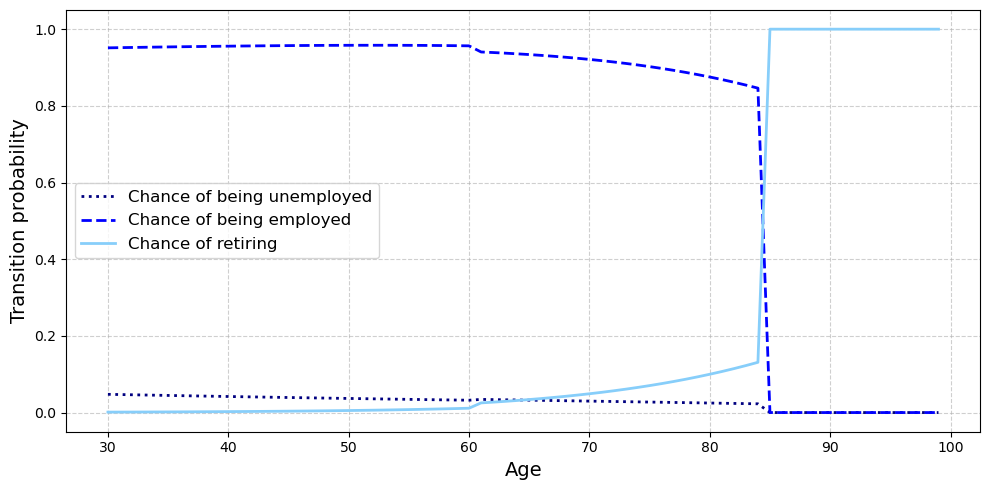

In [13]:
plt.figure(figsize=(10, 5))

time = np.arange(len(everything[0]["to_0"])) + 30

plt.plot(
    time,
    everything[0]["to_0"],
    label="Chance of being unemployed",
    color="navy",
    linestyle=":",
    linewidth=2
)
plt.plot(
    time,
    everything[0]["to_1"],
    label="Chance of being employed",
    color="blue",
    linestyle="--",
    linewidth=2
)
plt.plot(
    time,
    everything[0]["to_2"],
    label="Chance of retiring",
    color="lightskyblue",
    linewidth=2
)

plt.xlabel("Age", fontsize=14)
plt.ylabel("Transition probability", fontsize=14)
plt.title("", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

# Skatteprocenterne

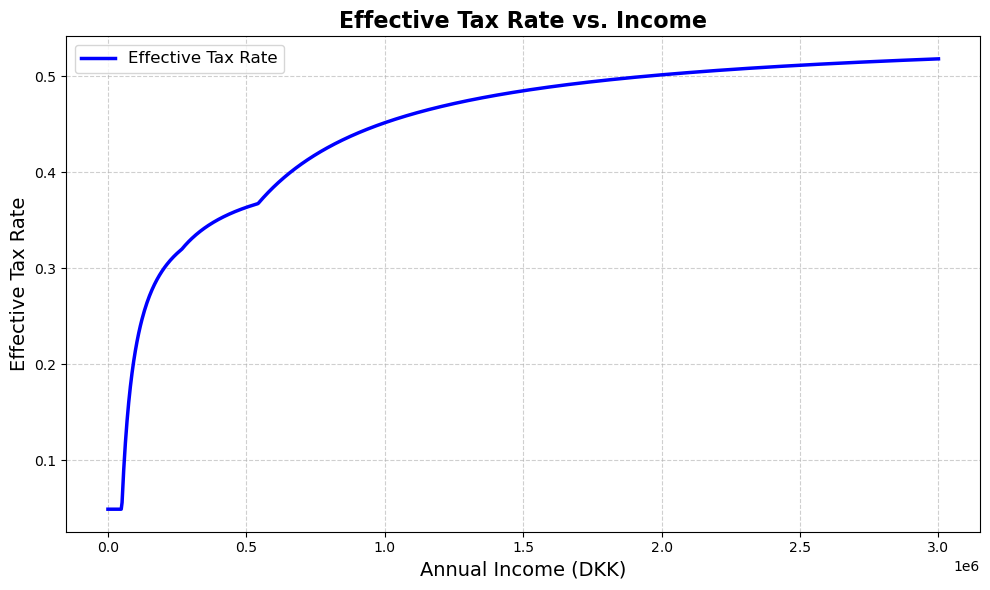

In [14]:
# Tax constants
am_sats = 0.08
beskfradrag_sats = 1- 0.875
bundskat_sats = 0.113
topskat_sats = 0.15
kommuneskat_sats = 0.2491
personfradrag = 46000
beskfradrag_graense = 33300
topskat_graense = 498900

def calculate_tax_rate(ind_aar):
    am_aar = ind_aar * am_sats
    personlignd_aar = ind_aar - am_aar
    grundlag_aar = max(personlignd_aar - personfradrag, 0)
    beskfradrag_aar = min(beskfradrag_graense, ind_aar * beskfradrag_sats)
    skattepligt_aar = grundlag_aar - beskfradrag_aar
    bundskat_aar = grundlag_aar * bundskat_sats
    topskat_aar = topskat_sats * max(personlignd_aar - topskat_graense, 0)
    kommuneskat_aar = kommuneskat_sats * skattepligt_aar
    indkomstskat_aar = am_aar + bundskat_aar + topskat_aar + kommuneskat_aar
    ind_efter_aar = ind_aar - indkomstskat_aar
    skatteprocent_aar = max(1 - (ind_efter_aar / ind_aar), 0)
    return skatteprocent_aar

# Generate data
incomes = np.linspace(1, 3_000_000, 1000)
tax_rates = [calculate_tax_rate(x) for x in incomes]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(incomes, tax_rates, label="Effective Tax Rate", color="blue", linewidth=2.5)
plt.xlabel("Annual Income (DKK)", fontsize=14)
plt.ylabel("Effective Tax Rate", fontsize=14)
plt.title("Effective Tax Rate vs. Income", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

